# Week 8: Complete Preprocessing Pipeline

---
## Internship Details

**Intern Name:** Dinesh Singh Dhami  
**Semester:** BE Computer 8th Semester  
**Company:** Sipalaya Info Tech, Kathmandu-32, Koteshwor  
**Domain:** Data Science  
**Final Assignment:** Complete Preprocessing Pipeline  
**Tools Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Jupyter Notebook  

---

## Objective

The objective of this assignment is to build a complete preprocessing pipeline on a housing dataset. The pipeline includes missing value handling, duplicate removal, outlier handling, encoding, scaling, visualization, and saving the final processed dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv("complete_preprocessing_pipeline_dataset.csv")
df.head()

,House_ID,Location,House_Type,Bedrooms,Bathrooms,Area_sqft,Age_Years,Parking,Price
0,3001,Kathmandu,Flat,3.0,1.0,800.0,1.0,NO,18000000.0
1,3002,Lalitpur,Apartment,2.0,2.0,NaN,18.0,Y,25000000.0
2,3003,Pokhara,Apartment,4.0,1.0,2200.0,25.0,Yes,12000000.0
3,3004,kathmandu,Flat,1.0,1.0,800.0,3.0,N,25000000.0
4,3005,POKHARA,Apartment,3.0,4.0,1200.0,NaN,yes,9000000.0


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   House_ID    50 non-null     int64  
 1   Location    50 non-null     object 
 2   House_Type  50 non-null     object 
 3   Bedrooms    46 non-null     float64
 4   Bathrooms   38 non-null     float64
 5   Area_sqft   42 non-null     float64
 6   Age_Years   44 non-null     float64
 7   Parking     50 non-null     object 
 8   Price       44 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 3.6+ KB


(50, 9)

### Missing Value Handling

In [4]:
df.isnull().sum()

House_ID       0
Location       0
House_Type     0
Bedrooms       4
Bathrooms     12
Area_sqft      8
Age_Years      6
Parking        0
Price          6
dtype: int64

In [5]:
df["Bedrooms"] = df["Bedrooms"].fillna(df["Bedrooms"].median())
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df["Area_sqft"] = df["Area_sqft"].fillna(df["Area_sqft"].median())
df["Age_Years"] = df["Age_Years"].fillna(df["Age_Years"].median())
df["Price"] = df["Price"].fillna(df["Price"].median())

df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
df["House_Type"] = df["House_Type"].fillna(df["House_Type"].mode()[0])
df["Parking"] = df["Parking"].fillna(df["Parking"].mode()[0])

### Duplicate Removal

In [6]:
df.duplicated().sum()

3

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

0

### String Cleaning

In [8]:
df["Location"] = df["Location"].str.strip().str.title()
df["House_Type"] = df["House_Type"].str.strip().str.title()
df["Parking"] = df["Parking"].str.strip().str.title()

df["Parking"] = df["Parking"].replace({
    "Y": "Yes",
    "N": "No"
})

### Outlier Handling using IQR

In [9]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]
outliers

,House_ID,Location,House_Type,Bedrooms,Bathrooms,Area_sqft,Age_Years,Parking,Price
45,3090,Kathmandu,Villa,8.0,6.0,9000.0,2.0,Yes,150000000.0


In [10]:
df["Price"] = np.where(df["Price"] > upper, upper, df["Price"])
df["Price"] = np.where(df["Price"] < lower, lower, df["Price"])

### Feature Engineering

In [11]:
df["Price_per_sqft"] = df["Price"] / df["Area_sqft"]
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]
df["New_House"] = np.where(df["Age_Years"] <= 5, 1, 0)
df["Big_House"] = np.where(df["Area_sqft"] >= 2000, 1, 0)

### Encoding

In [12]:
encoder = LabelEncoder()

df["Location"] = encoder.fit_transform(df["Location"])
df["House_Type"] = encoder.fit_transform(df["House_Type"])
df["Parking"] = encoder.fit_transform(df["Parking"])

### Scaling

In [13]:
numeric_cols = [
    "Bedrooms", "Bathrooms", "Area_sqft", "Age_Years",
    "Price", "Price_per_sqft", "Total_Rooms"
]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

### Visualization

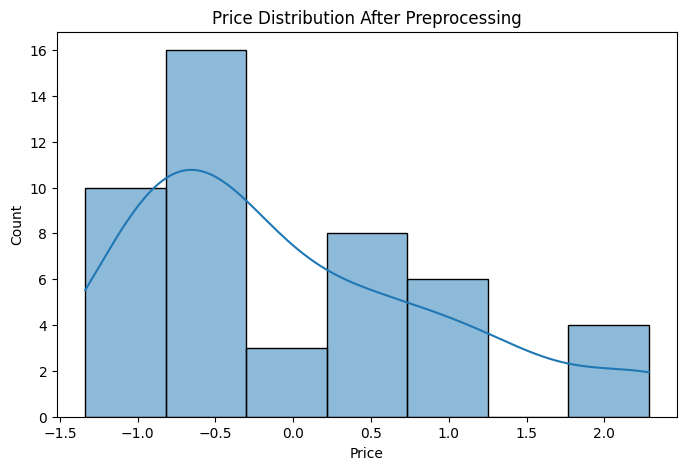

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution After Preprocessing")
plt.show()

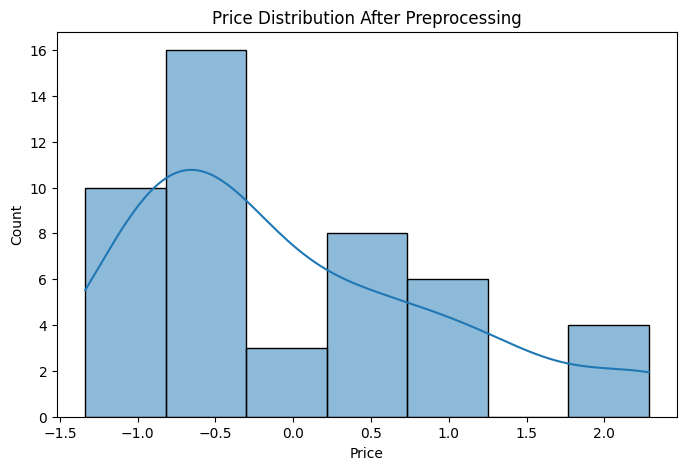

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution After Preprocessing")
plt.show()

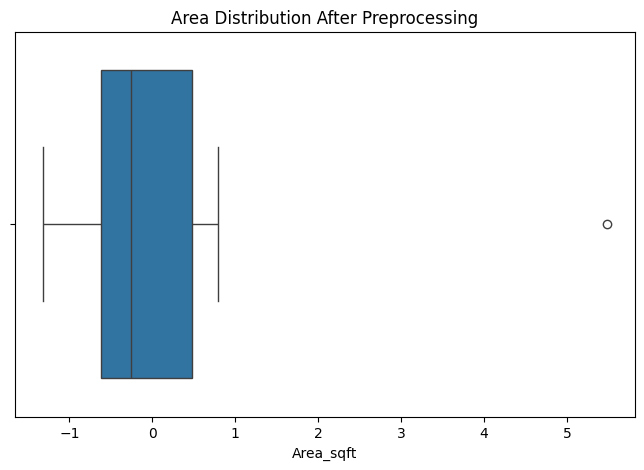

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Area_sqft"])
plt.title("Area Distribution After Preprocessing")
plt.show()

### Final Check

In [17]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 46
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   House_ID        47 non-null     int64  
 1   Location        47 non-null     int32  
 2   House_Type      47 non-null     int32  
 3   Bedrooms        47 non-null     float64
 4   Bathrooms       47 non-null     float64
 5   Area_sqft       47 non-null     float64
 6   Age_Years       47 non-null     float64
 7   Parking         47 non-null     int32  
 8   Price           47 non-null     float64
 9   Price_per_sqft  47 non-null     float64
 10  Total_Rooms     47 non-null     float64
 11  New_House       47 non-null     int32  
 12  Big_House       47 non-null     int32  
dtypes: float64(7), int32(5), int64(1)
memory usage: 4.2 KB


House_ID          0
Location          0
House_Type        0
Bedrooms          0
Bathrooms         0
Area_sqft         0
Age_Years         0
Parking           0
Price             0
Price_per_sqft    0
Total_Rooms       0
New_House         0
Big_House         0
dtype: int64

In [18]:
df.head()

,House_ID,Location,House_Type,Bedrooms,Bathrooms,Area_sqft,Age_Years,Parking,Price,Price_per_sqft,Total_Rooms,New_House,Big_House
0,3001,2,1,0.000000,-1.155860,-0.928410,-1.511447,0,0.450672,1.427998,-0.626305,1,0
1,3002,3,0,-0.642091,-0.345033,-0.264310,0.525056,1,1.195565,0.632940,-0.626305,0,0
2,3003,4,0,0.642091,-1.155860,0.165402,1.363616,1,-0.187808,-0.416208,-0.186957,0,1
3,3004,2,1,-1.284182,-1.155860,-0.928410,-1.271859,0,1.195565,2.374690,-1.505002,1,0
4,3005,4,0,0.000000,1.276621,-0.615893,0.525056,1,-0.507048,-0.194903,0.691740,0,0


### Save Final Dataset

In [19]:
df.to_csv("final_preprocessed_housing_dataset.csv", index=False)

## Conclusion

In this assignment, I built a complete preprocessing pipeline on a housing dataset. I handled missing values, removed duplicate records, cleaned string columns, detected and capped outliers using IQR, encoded categorical features, scaled numerical features, created new engineered features, and visualized the cleaned dataset. The final dataset is ready for machine learning.